# Setup and Initialization

## Import Libraries

In [10]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [23]:
np.set_printoptions(precision=2, suppress=True)
pd.options.display.float_format = '{:.2f}'.format

## Data Loading

In [7]:
KAGGLE_PATH = Path("/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1")
LOCAL_PATH = Path("./data")

DATA_DIR = KAGGLE_PATH if KAGGLE_PATH.exists() else LOCAL_PATH

print("DATA_DIR set to:")
print(DATA_DIR)

DATA_DIR set to:
data


In [8]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print("Train rows:", train.shape[0])
print("Train columns:", train.shape[1])

print("Test rows:", test.shape[0])
print("Test columns:", test.shape[1])

Train rows: 10000
Train columns: 17
Test rows: 1500
Test columns: 17


In [28]:
col_mid = train.shape[1] // 2

print("Train data preview - Part 1 (First half of columns):")
display(train.iloc[:, :col_mid].head())

print("Train data preview - Part 2 (Remaining columns):")
display(train.iloc[:, col_mid:].head())

Train data preview - Part 1 (First half of columns):


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID
0,0,2023-06-28 17:31:46,2023-06-28 18:22:12,1.00,1.50,1.00,N,212
1,0,2023-06-29 19:15:55,2023-06-29 19:07:31,1.00,3.80,1.00,N,6
2,1,2023-06-30 18:28:50,2023-06-30 18:01:19,2.00,1.89,1.00,N,35
3,1,2023-06-30 22:57:37,2023-06-30 22:55:34,1.00,1.10,1.00,N,46
4,1,2023-06-28 18:39:16,2023-06-28 17:31:29,2.00,2.84,1.00,N,213


Train data preview - Part 2 (Remaining columns):


,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,237,Credit Card,5.00,6.53,0.00,1.00,24.80,2.50,0.00
1,163,Credit Card,5.00,9.19,0.00,1.00,31.55,2.50,0.00
2,81,Credit Card,2.50,6.79,0.00,1.00,24.84,2.50,0.00
3,99,Credit Card,1.00,3.70,0.00,1.00,13.45,2.50,0.00
4,114,Credit Card,2.50,7.84,0.00,1.00,29.88,2.50,0.00


### Column Data Types

In [12]:
print("Displaying basic info for train dataset:")
train.info()

Displaying basic info for train dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        9634 non-null   float64
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             9634 non-null   float64
 6   store_and_fwd_flag     9634 non-null   object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount  

In [17]:
# Identifying numerical and categorical columns
numerical_cols = train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = train.select_dtypes(exclude=['number']).columns.tolist()

In [18]:
print("Numerical column count:")
print(len(numerical_cols))

print("Numerical columns:")
print(numerical_cols)

Numerical column count:
13
Numerical columns:
['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'extra', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [19]:
print("Categorical column count:")
print(len(categorical_cols))

print("Categorical columns:")
print(categorical_cols)

Categorical column count:
4
Categorical columns:
['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag', 'payment_type']


# Exploratory Data Analysis

## Descriptive Statistics

### Numerical Summary

In [25]:
# Split the numerical columns list into two halves
mid_point = len(numerical_cols) // 2
first_half = numerical_cols[:mid_point]
second_half = numerical_cols[mid_point:]

print("Descriptive statistics - Part 1:")
stats_part1 = train[first_half].describe(percentiles=[.75]).loc[['mean', 'min', '75%', 'max']]
display(stats_part1)

print("Descriptive statistics - Part 2:")
stats_part2 = train[second_half].describe(percentiles=[.75]).loc[['mean', 'min', '75%', 'max']]
display(stats_part2)

Descriptive statistics - Part 1:


,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID
mean,0.73,1.36,3.68,1.45,132.71,132.33
min,0.00,0.00,0.00,1.00,1.00,1.00
75%,1.00,1.00,3.63,1.00,198.00,199.00
max,2.00,6.00,71.94,99.00,264.00,264.00


Descriptive statistics - Part 2:


,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
mean,1.94,6.09,0.66,0.98,29.74,2.24,0.16
min,-7.50,0.00,-26.55,-1.00,-129.30,-2.50,-1.75
75%,2.50,7.46,0.00,1.00,31.80,2.50,0.00
max,11.75,84.03,32.05,1.00,551.00,2.50,1.75


### Visualizing Distributions

Histograms for numerical features.


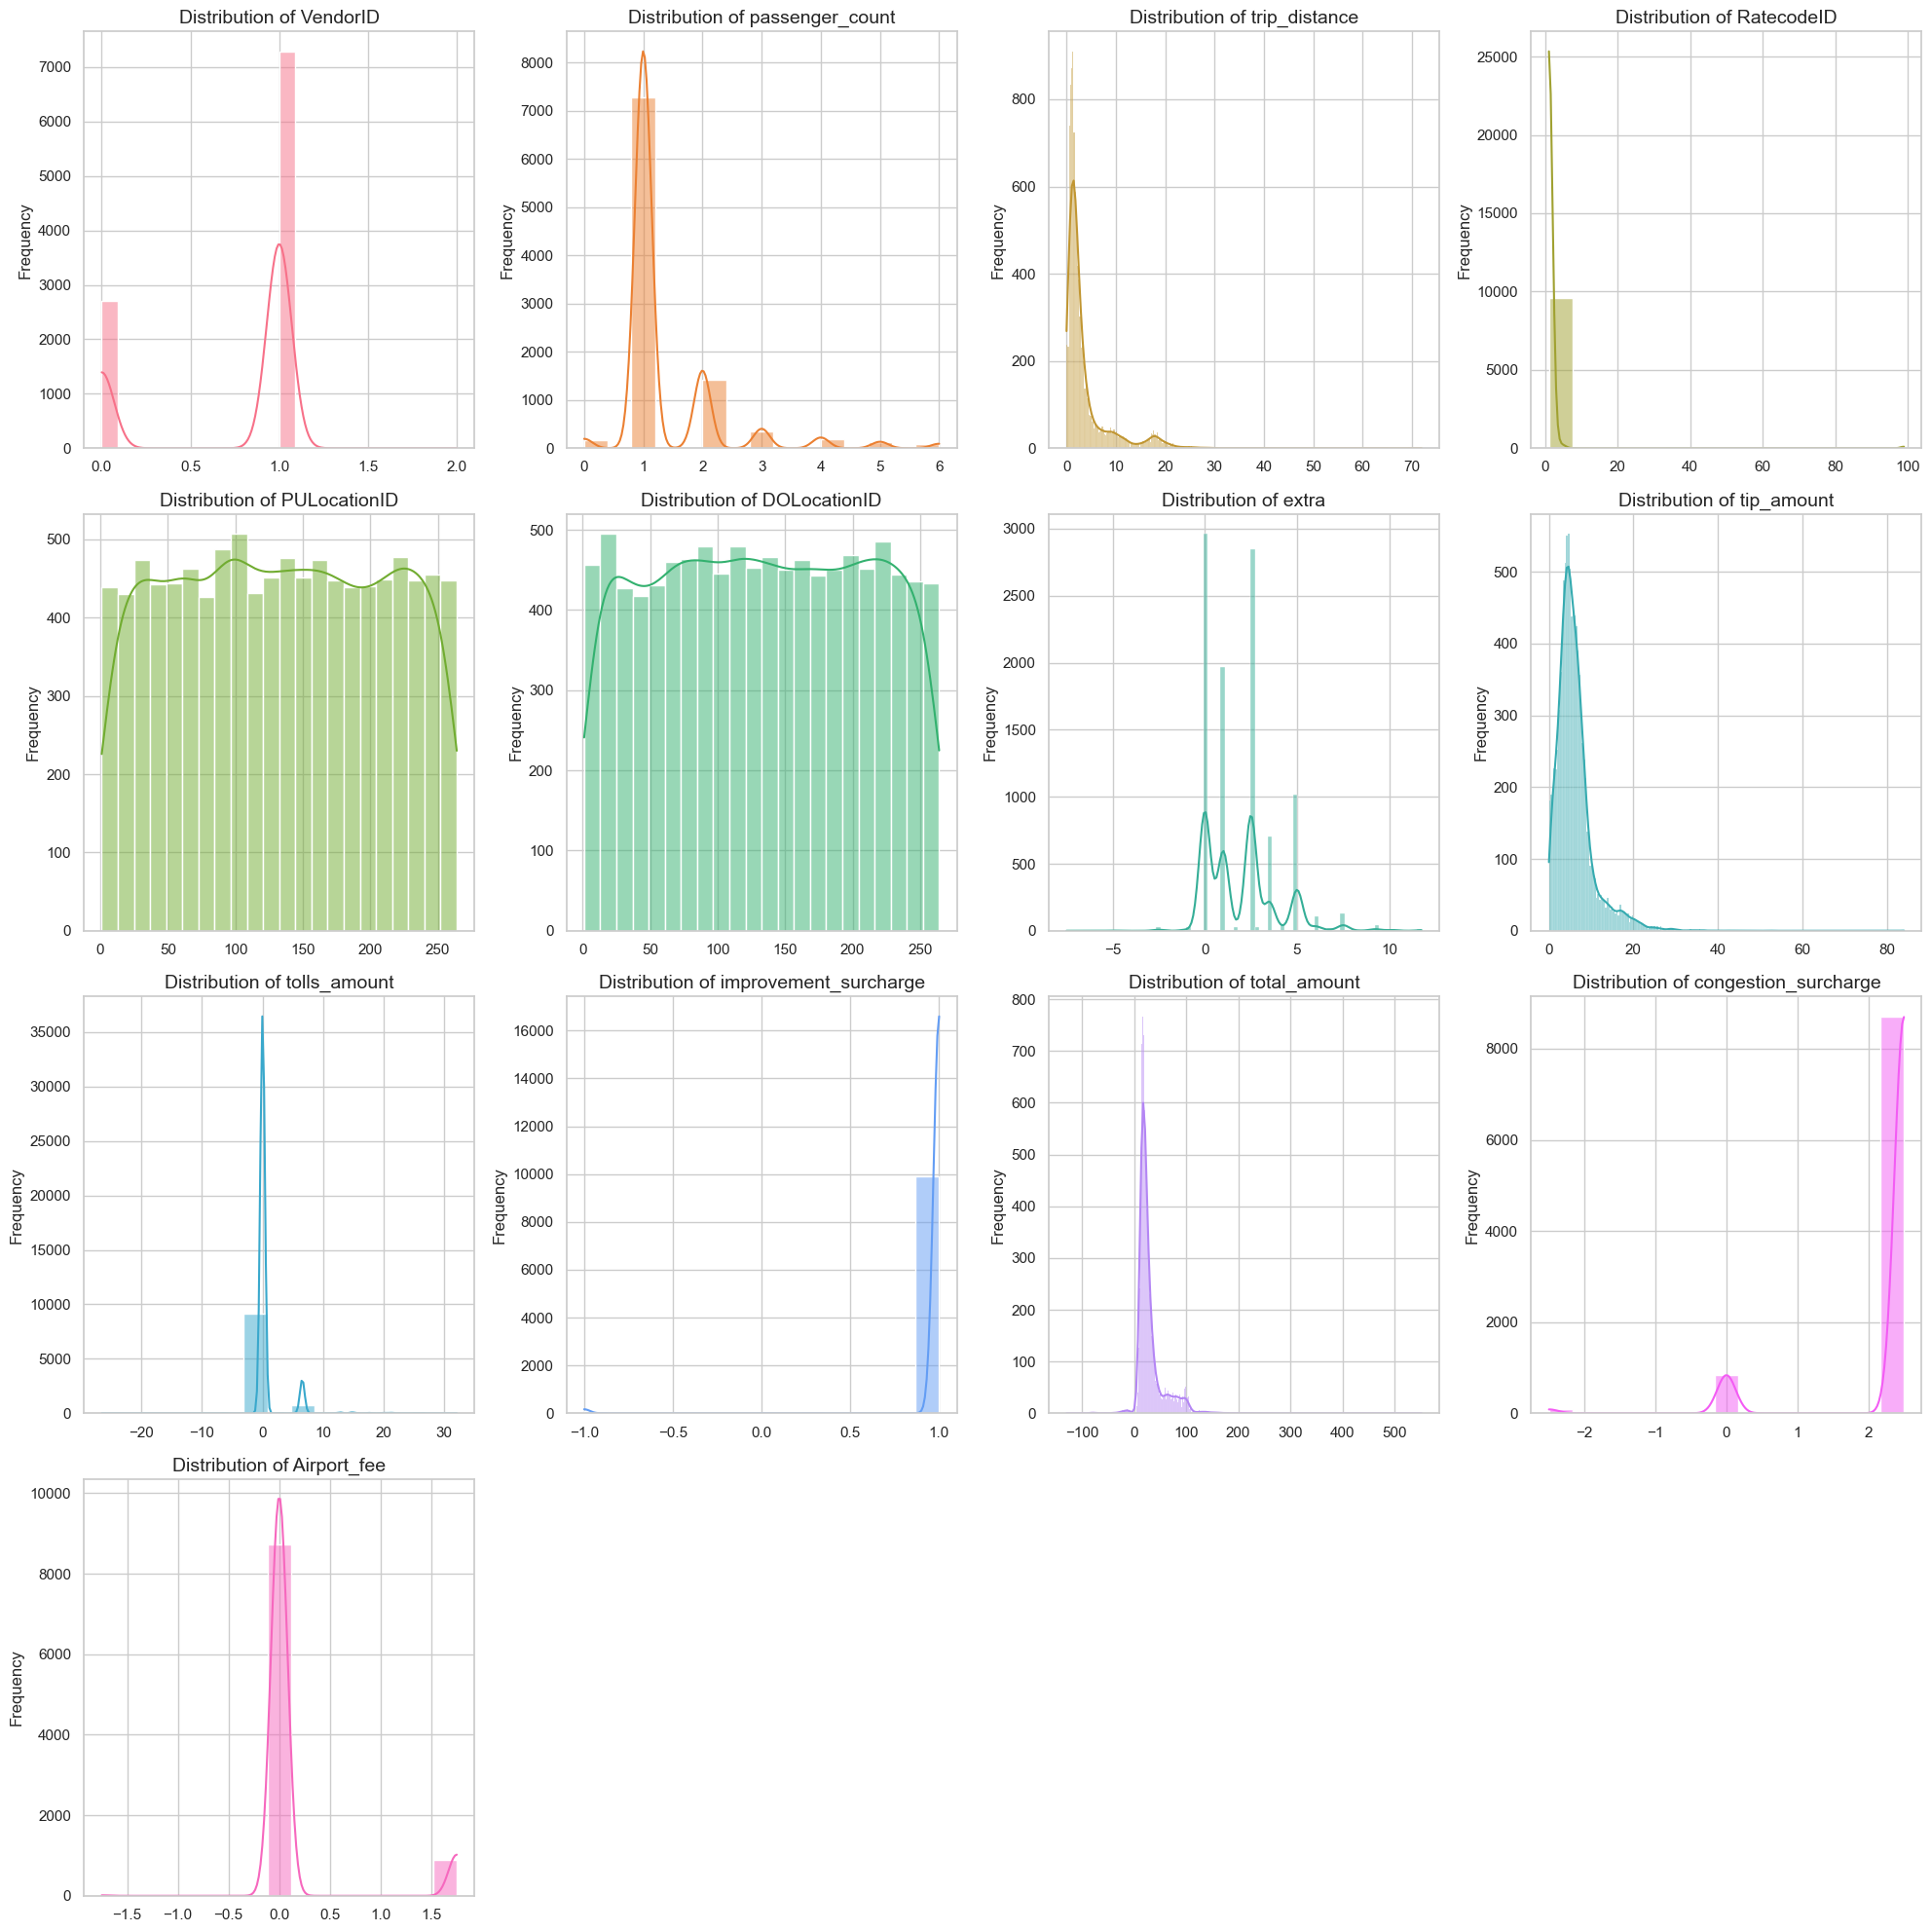

In [30]:
print("Histograms for numerical features.")

n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

_ = plt.figure(figsize=(20, 5 * n_rows))
_ = sns.set_theme(style="whitegrid")

for i, col in enumerate(numerical_cols):
  _ = plt.subplot(n_rows, n_cols, i + 1)
  _ = sns.histplot(train[col], kde=True, color=sns.color_palette("husl", len(numerical_cols))[i])
  _ = plt.title(f"Distribution of {col}", fontsize=14)
  _ = plt.xlabel("")
  _ = plt.ylabel("Frequency")

plt.tight_layout()

## Categorical and Temporal Column Analysis

### Temporal Features

In [31]:
# Converting temporal columns to datetime objects.
train['tpep_pickup_datetime'] = pd.to_datetime(train['tpep_pickup_datetime'])
train['tpep_dropoff_datetime'] = pd.to_datetime(train['tpep_dropoff_datetime'])

# Extracting hour and day of week from pickup datetime.
train['pickup_hour'] = train['tpep_pickup_datetime'].dt.hour
train['pickup_day'] = train['tpep_pickup_datetime'].dt.day_name()

print("Row counts for each hour of the day:")
hour_counts = train['pickup_hour'].value_counts().sort_index().reset_index()
hour_counts.columns = ['Hour', 'Row Count']
display(hour_counts)

print("Row counts for each day of the week:")
day_counts = train['pickup_day'].value_counts().reset_index()
day_counts.columns = ['Day of Week', 'Row Count']
display(day_counts)

Row counts for each hour of the day:


,Hour,Row Count
0,0,262
1,1,145
2,2,83
3,3,68
4,4,63
5,5,74
6,6,148
7,7,226
8,8,301
9,9,343


Row counts for each day of the week:


,Day of Week,Row Count
0,Thursday,4167
1,Friday,3866
2,Wednesday,1928
3,Saturday,39


Plotting hour and day of week frequencies.


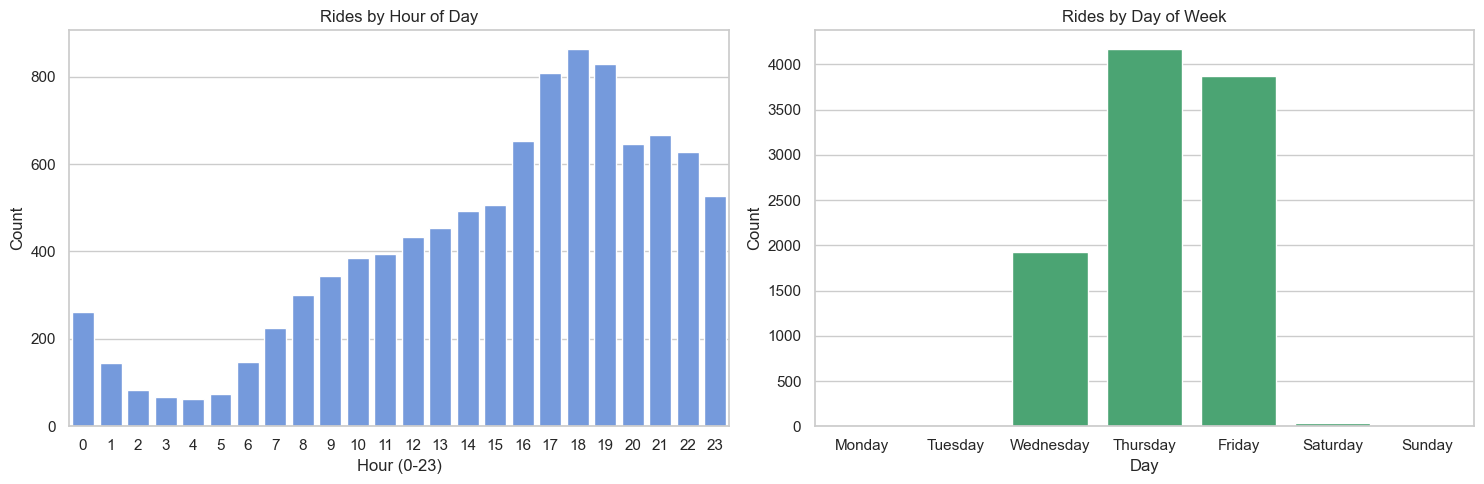

In [33]:
print("Plotting hour and day of week frequencies.")
_ = plt.figure(figsize=(15, 5))
_ = sns.set_theme(style="whitegrid")

_ = plt.subplot(1, 2, 1)
_ = sns.countplot(x='pickup_hour', data=train, color='cornflowerblue')
_ = plt.title("Rides by Hour of Day")
_ = plt.xlabel("Hour (0-23)")
_ = plt.ylabel("Count")

_ = plt.subplot(1, 2, 2)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
_ = sns.countplot(x='pickup_day', data=train, order=days_order, color='mediumseagreen')
_ = plt.title("Rides by Day of Week")
_ = plt.xlabel("Day")
_ = plt.ylabel("Count")

plt.tight_layout()

### Other Categorical Features

In [34]:
print("Row counts for store_and_fwd_flag:")
flag_counts = train['store_and_fwd_flag'].value_counts().reset_index()
flag_counts.columns = ['Store and Fwd Flag', 'Row Count']
display(flag_counts)

print("Row counts for payment_type:")
payment_counts = train['payment_type'].value_counts().reset_index()
payment_counts.columns = ['Payment Type', 'Row Count']
display(payment_counts)

Row counts for store_and_fwd_flag:


,Store and Fwd Flag,Row Count
0,N,9565
1,Y,69


Row counts for payment_type:


,Payment Type,Row Count
0,Credit Card,7727
1,Cash,1706
2,Wallet,366
3,unknown,133
4,UPI,68


Plotting categorical feature distributions.


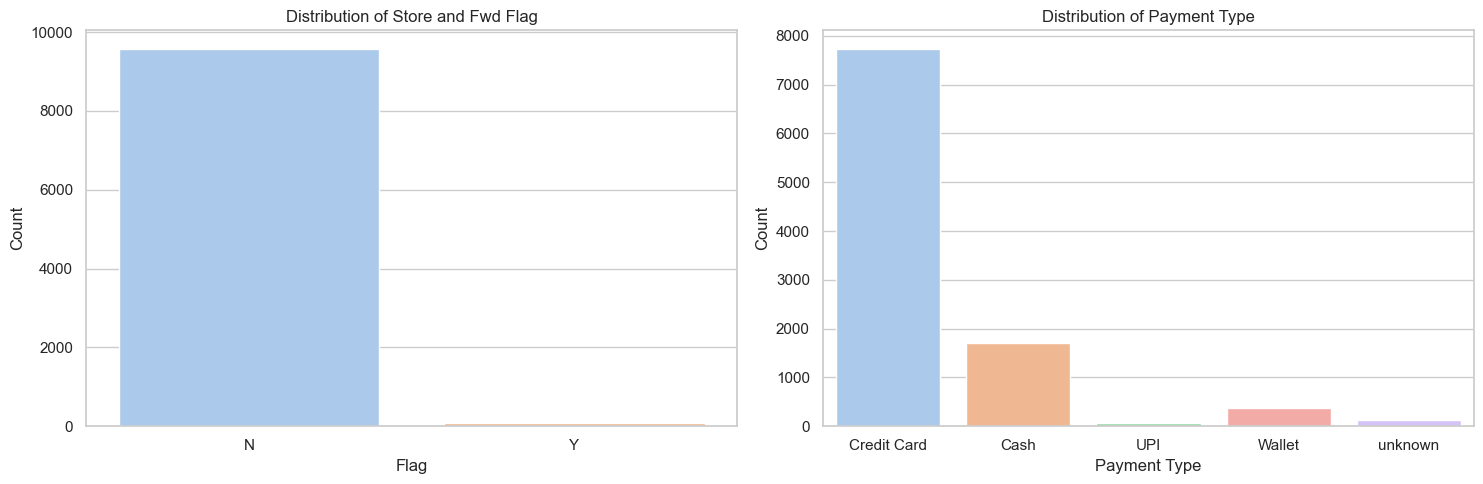

In [36]:
print("Plotting categorical feature distributions.")
_ = plt.figure(figsize=(15, 5))

_ = plt.subplot(1, 2, 1)
_ = sns.countplot(
    x='store_and_fwd_flag',
    hue='store_and_fwd_flag',
    data=train,
    palette='pastel',
    legend=False
)
_ = plt.title("Distribution of Store and Fwd Flag")
_ = plt.xlabel("Flag")
_ = plt.ylabel("Count")

_ = plt.subplot(1, 2, 2)
_ = sns.countplot(
    x='payment_type',
    hue='payment_type',
    data=train,
    palette='pastel',
    legend=False
)
_ = plt.title("Distribution of Payment Type")
_ = plt.xlabel("Payment Type")
_ = plt.ylabel("Count")

plt.tight_layout()

## Identify and Handle Missing Values

### Identify Missing Values

In [37]:
print("Missing values report for numerical columns:")
num_missing = train[numerical_cols].isnull().sum()
num_pct = (num_missing / len(train)) * 100
num_report = pd.DataFrame({
    'Missing Count': num_missing,
    'Percentage (%)': num_pct
})
display(num_report.sort_values(by='Missing Count', ascending=False))

Missing values report for numerical columns:


,Missing Count,Percentage (%)
passenger_count,366,3.66
RatecodeID,366,3.66
congestion_surcharge,366,3.66
Airport_fee,366,3.66
VendorID,0,0.00
PULocationID,0,0.00
trip_distance,0,0.00
DOLocationID,0,0.00
extra,0,0.00
tolls_amount,0,0.00


In [38]:
print("Missing values report for categorical columns:")
cat_missing = train[categorical_cols].isnull().sum()
cat_pct = (cat_missing / len(train)) * 100
cat_report = pd.DataFrame({
    'Missing Count': cat_missing,
    'Percentage (%)': cat_pct
})
display(cat_report.sort_values(by='Missing Count', ascending=False))

Missing values report for categorical columns:


,Missing Count,Percentage (%)
store_and_fwd_flag,366,3.66
tpep_pickup_datetime,0,0.00
tpep_dropoff_datetime,0,0.00
payment_type,0,0.00


### Handle Missing Values

In [42]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

In [43]:
# Imputing numerical features with median.
num_features = [col for col in numerical_cols if col != 'total_amount']
train[num_features] = num_imputer.fit_transform(train[num_features])
test[num_features] = num_imputer.transform(test[num_features])

# Imputing categorical features with most frequent.
train[categorical_cols] = cat_imputer.fit_transform(train[categorical_cols])
test[categorical_cols] = cat_imputer.transform(test[categorical_cols])

print("Total missing values in train after imputation:")
print(train.isnull().sum().sum())

print("Total missing values in test after imputation:")
print(test.isnull().sum().sum())

Total missing values in train after imputation:
0
Total missing values in test after imputation:
0


## Identify and Handle Duplicates

### Identify Duplicates

In [46]:
duplicates_count = train.duplicated().sum()
print("Number of duplicate rows found:")
print(duplicates_count)

Number of duplicate rows found:
0


### Drop Duplicates

In [47]:
if duplicates_count > 0:
  print("Dropping duplicate rows from train data.")
  train = train.drop_duplicates()

  print("New train data shape:")
  print(train.shape)
else:
  print("No duplicates to drop.")

No duplicates to drop.


## Identify and Handle Outliers

### Outlier Identification via Percentiles

In [48]:
# Calculating percentiles for numerical columns.
percentiles = [0, 0.5, 0.75, 0.90, 0.99, 1.0]
percentile_stats = train[numerical_cols].quantile(percentiles).T
percentile_stats.columns = [
    'Minimum', 'Median', '75th Percentile',
    '90th Percentile', '99th Percentile', 'Maximum'
]

print("Percentile statistics:")
display(percentile_stats)

Percentile statistics:


,Minimum,Median,75th Percentile,90th Percentile,99th Percentile,Maximum
VendorID,0.00,1.00,1.00,1.00,1.00,2.00
passenger_count,0.00,1.00,1.00,2.00,5.00,6.00
trip_distance,0.00,1.82,3.63,9.70,21.24,71.94
RatecodeID,1.00,1.00,1.00,1.00,4.00,99.00
PULocationID,1.00,133.00,198.00,237.00,262.00,264.00
DOLocationID,1.00,132.00,199.00,237.00,262.00,264.00
extra,-7.50,1.75,2.50,5.00,7.50,11.75
tip_amount,0.00,5.21,7.46,10.79,22.03,84.03
tolls_amount,-26.55,0.00,0.00,0.00,6.55,32.05
improvement_surcharge,-1.00,1.00,1.00,1.00,1.00,1.00


### Outlier Identification via Interquartile Range (IQR)

In [49]:
# Calculating IQR bounds and outlier counts.
outlier_info = []

for col in numerical_cols:
  q1 = train[col].quantile(0.25)
  q3 = train[col].quantile(0.75)
  iqr = q3 - q1

  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr

  outliers_mask = (train[col] < lower_bound) | (train[col] > upper_bound)
  outlier_count = outliers_mask.sum()
  outlier_pct = (outlier_count / len(train)) * 100

  outlier_info.append({
      'Feature': col,
      'Lower Bound': lower_bound,
      'Upper Bound': upper_bound,
      'Outlier Count': outlier_count,
      'Outlier Percentage (%)': outlier_pct
  })

outlier_df = pd.DataFrame(outlier_info).set_index('Feature')

print("IQR bounds and outlier statistics:")
display(outlier_df)

IQR bounds and outlier statistics:


,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
Feature,,,,
VendorID,-1.50,2.50,0,0.00
passenger_count,1.00,1.00,2352,23.52
trip_distance,-2.77,7.47,1354,13.54
RatecodeID,1.00,1.00,577,5.77
PULocationID,-129.50,394.50,0,0.00
DOLocationID,-128.50,395.50,0,0.00
extra,-3.75,6.25,242,2.42
tip_amount,-2.52,13.44,657,6.57
tolls_amount,0.00,0.00,884,8.84


### Outlier Visualization

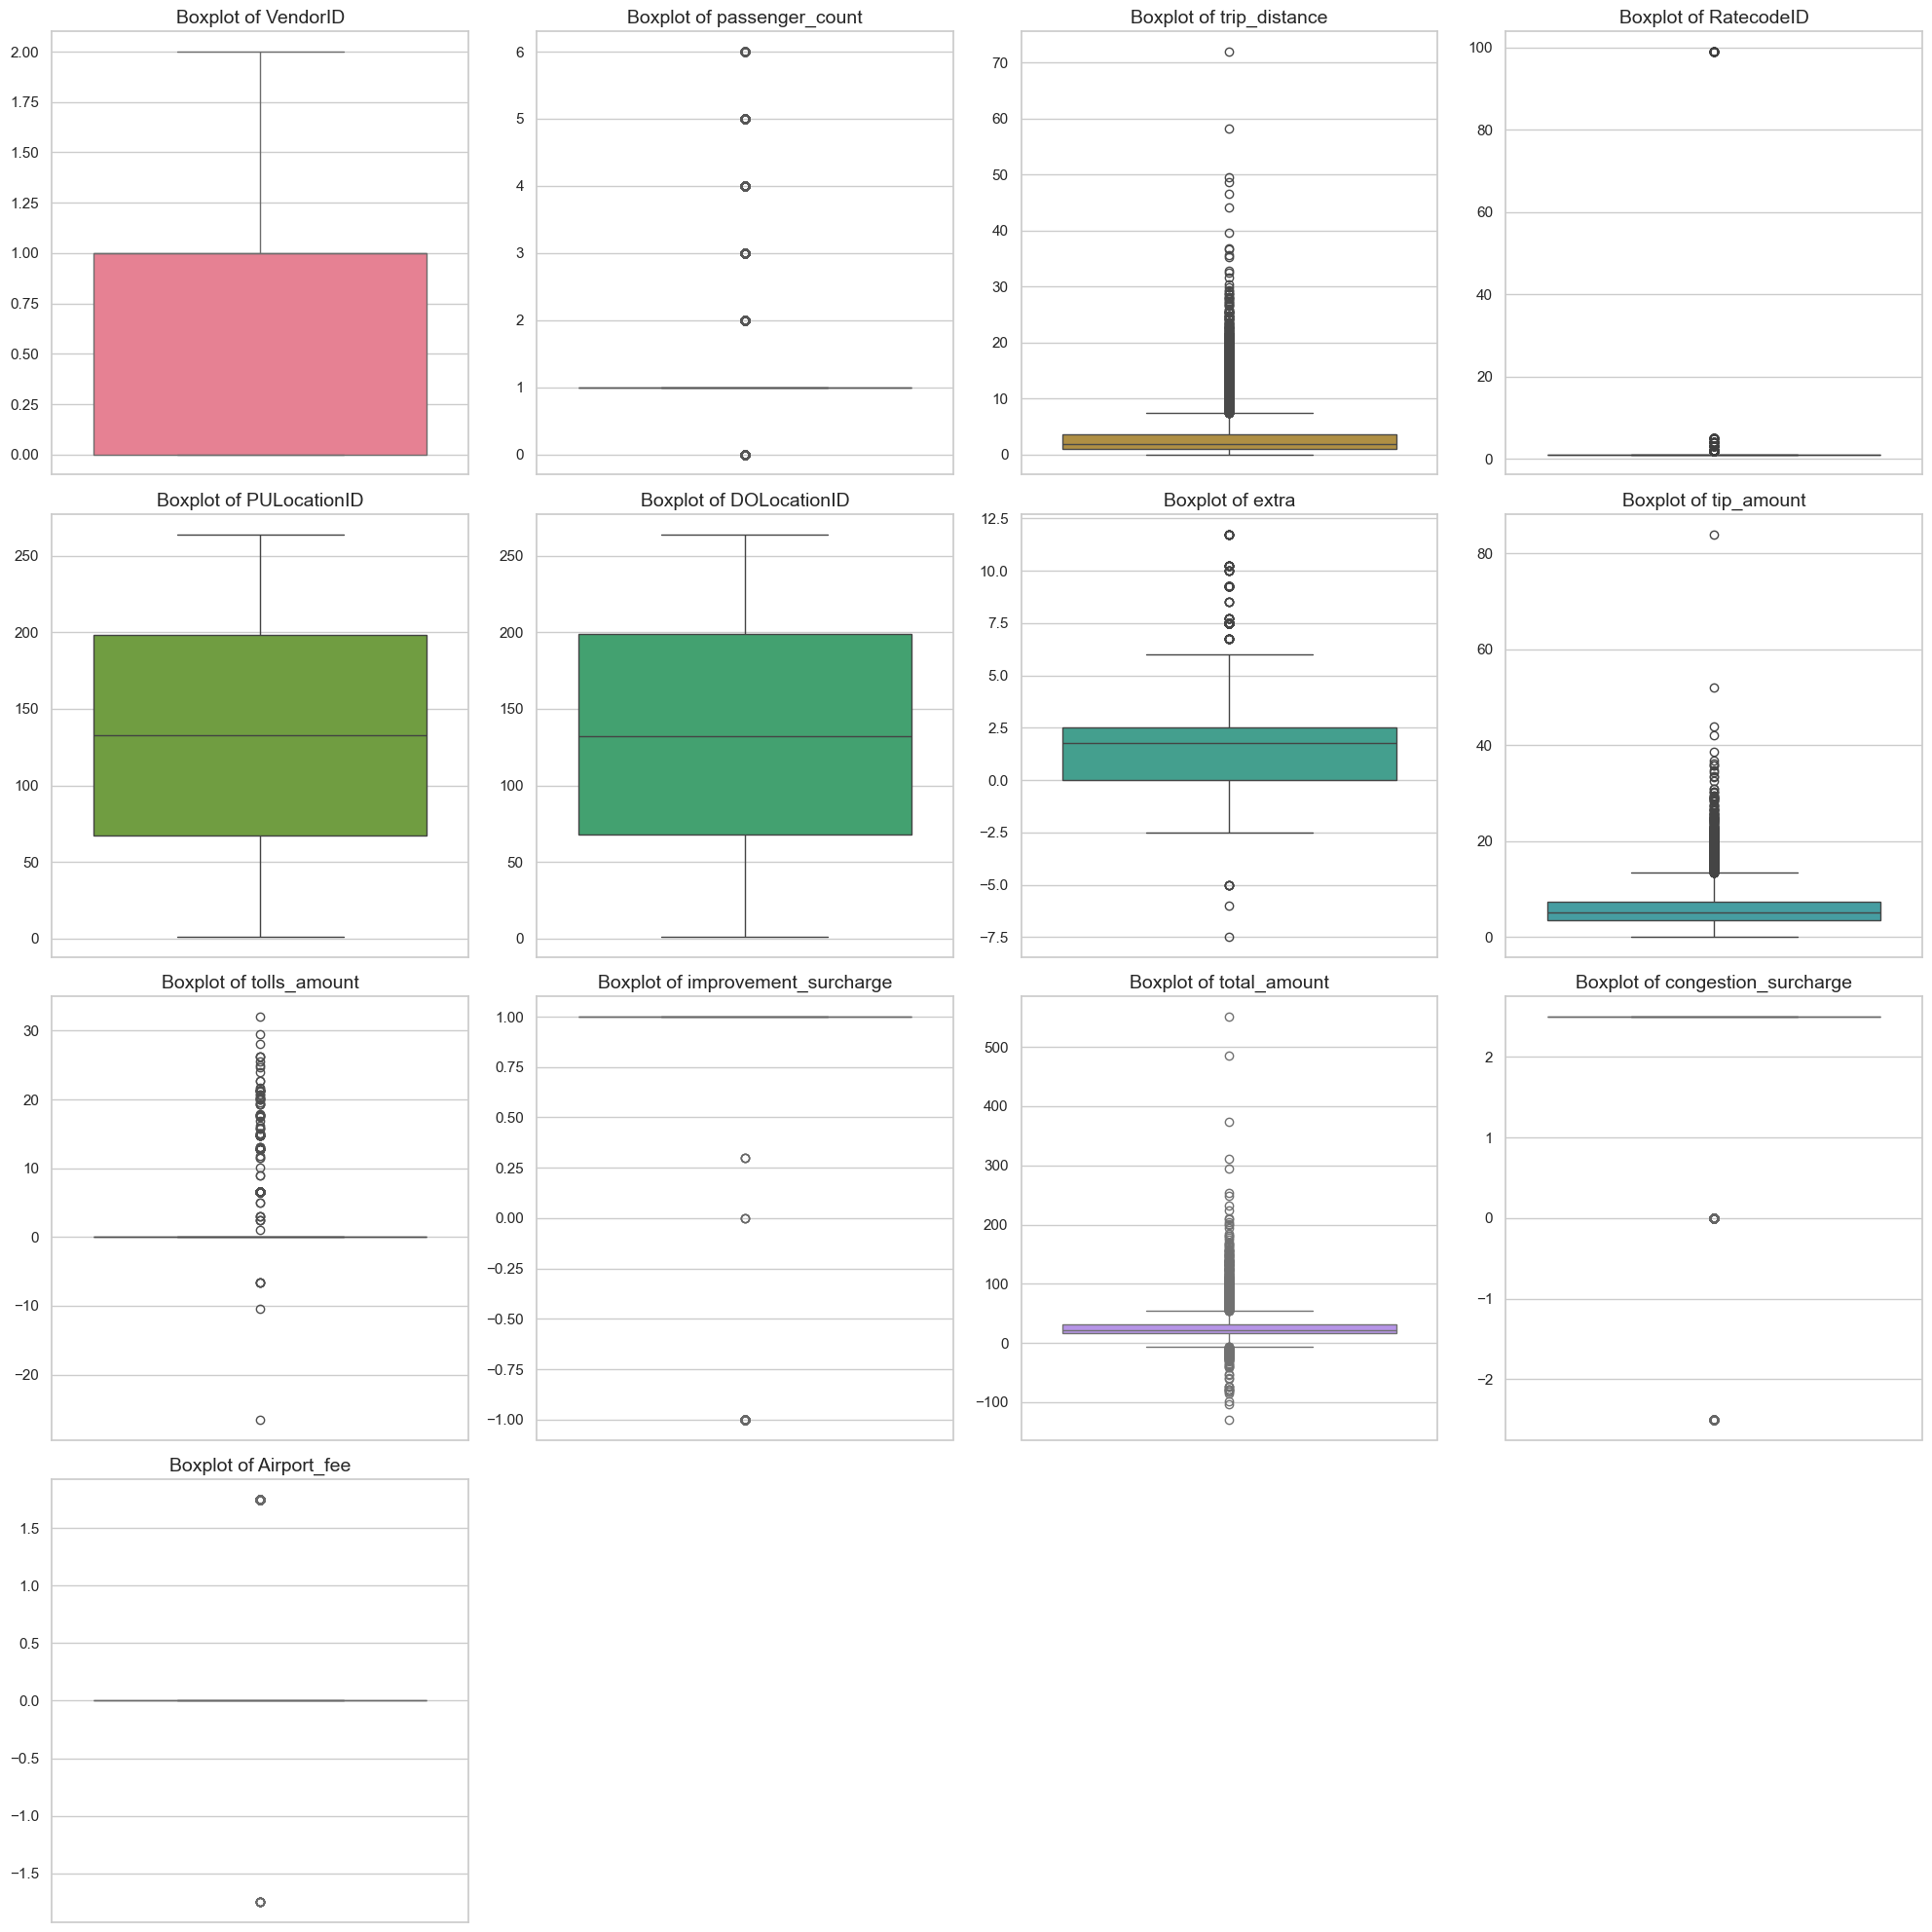

In [51]:
# Plotting box plots for numerical columns.
n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

_ = plt.figure(figsize=(20, 5 * n_rows))
_ = sns.set_theme(style="whitegrid")

for i, col in enumerate(numerical_cols):
  _ = plt.subplot(n_rows, n_cols, i + 1)
  _ = sns.boxplot(y=train[col], color=sns.color_palette("husl", len(numerical_cols))[i])
  _ = plt.title(f"Boxplot of {col}", fontsize=14)
  _ = plt.ylabel("")

plt.tight_layout()